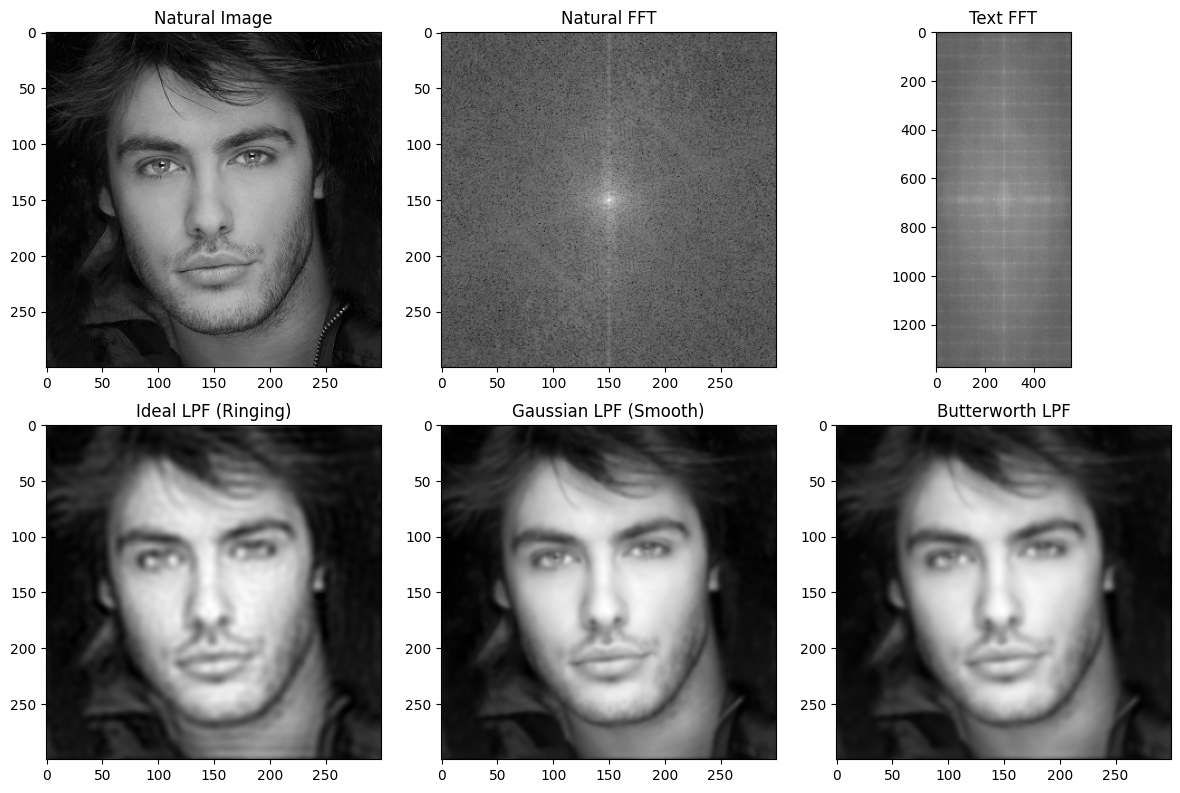

In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

def apply_fft(img):
    dft = np.fft.fft2(img)
    dft_shift = np.fft.fftshift(dft)
    magnitude_spectrum = 20 * np.log(np.abs(dft_shift) + 1)
    return dft_shift, magnitude_spectrum

def create_filters(shape, d0, n=2):
    rows, cols = shape
    crow, ccol = rows // 2, cols // 2
    x = np.linspace(0, cols - 1, cols)
    y = np.linspace(0, rows - 1, rows)
    X, Y = np.meshgrid(x, y)

    # Calculate Euclidean Distance D(u,v)
    D = np.sqrt((X - ccol)**2 + (Y - crow)**2)

    # 1. Ideal Low Pass Filter
    ideal_lpf = np.zeros((rows, cols))
    ideal_lpf[D <= d0] = 1

    # 2. Gaussian Low Pass Filter
    gaussian_lpf = np.exp(-(D**2) / (2 * (d0**2)))

    # 3. Butterworth Low Pass Filter
    butterworth_lpf = 1 / (1 + (D / d0)**(2 * n))

    return ideal_lpf, gaussian_lpf, butterworth_lpf

def filter_image(dft_shift, filter_mask):
    fshift = dft_shift * filter_mask
    f_ishift = np.fft.ifftshift(fshift)
    img_back = np.fft.ifft2(f_ishift)
    return np.abs(img_back)

# --- Main DIY Execution ---
# 1. Load two different types of images
img1 = cv2.imread('/content/drive/MyDrive/Sample images/teenager.jpg', 0) # Natural image
img2 = cv2.imread('/content/drive/MyDrive/Sample images/receiptocr.jpg', 0) # Text/Document image

# 2. Analyze Frequency Components
dft1, mag1 = apply_fft(img1)
dft2, mag2 = apply_fft(img2)

# 3. Apply Filters (using img1 as example)
d0_value = 30
ideal, gaussian, butter = create_filters(img1.shape, d0_value)

res_ideal = filter_image(dft1, ideal)
res_gaussian = filter_image(dft1, gaussian)
res_butter = filter_image(dft1, butter)

# Visualization
plt.figure(figsize=(12, 8))
plt.subplot(231), plt.imshow(img1, cmap='gray'), plt.title('Natural Image')
plt.subplot(232), plt.imshow(mag1, cmap='gray'), plt.title('Natural FFT')
plt.subplot(233), plt.imshow(mag2, cmap='gray'), plt.title('Text FFT')
plt.subplot(234), plt.imshow(res_ideal, cmap='gray'), plt.title('Ideal LPF (Ringing)')
plt.subplot(235), plt.imshow(res_gaussian, cmap='gray'), plt.title('Gaussian LPF (Smooth)')
plt.subplot(236), plt.imshow(res_butter, cmap='gray'), plt.title('Butterworth LPF')
plt.tight_layout()
plt.show()